# 01. Exploratory Data Analysis: Walmart M5 Hierarchical Demand Forecasting

## 1. Project Context & Objectives
The **M5 Forecasting Challenge** involves predicting daily unit sales for **30,490 items** across **10 stores** in **3 US states** (California, Texas, Wisconsin) over a **28-day horizon**.

### Key Objectives of this EDA:
1. **Hierarchy Profiling**: Analyze demand aggregation across 12 levels (Total -> State -> Store -> Category -> Department -> Item).
2. **Intermittency & Zero-Inflation**: Characterize non-continuous demand patterns using the Syntetos-Boylan classification (Smooth, Intermittent, Erratic, Lumpy).
3. **Exogenous Drivers**: Quantify the impact of **SNAP benefit cycles**, calendar events (holidays, weekends), and **price dynamics** (discounts, elasticity).
4. **Stationarity & Seasonality**: Perform ADF & KPSS statistical tests and seasonal decomposition (7-day weekly, 28-day monthly, annual cycles).

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss

# Add root to sys.path
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(root_dir))

from src.data.loader import generate_synthetic_m5_data, load_raw_data
from src.data.preprocess import melt_sales_data, merge_calendar_and_prices
from src.utils.config import load_config
from src.utils.logger import get_logger

# Plot styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

config = load_config(root_dir / "configs" / "model_config.yaml")
logger = get_logger("eda_notebook")
print(f"Project: {config.project.get('name')} | Horizon: {config.forecast.horizon} days")

Project: retail-demand-forecast-engine | Horizon: 28 days


### Environment & Setup Analysis
Configuration is loaded dynamically from `configs/model_config.yaml`. In the next step, we load the raw M5 datasets with optimized Polars chunking (or fallback to synthetic M5 data if offline).

In [4]:
# Load a representative sample of series across multiple stores/departments for high-speed EDA
SAMPLE_SERIES = 150

try:
    calendar_df, prices_df, sales_df = load_raw_data(root_dir / "data" / "raw", nrows=SAMPLE_SERIES)
    print(f"Loaded {len(sales_df)} M5 item-store series from data/raw")
except Exception as e:
    print(
        f"Raw data not found ({e}). Generating high-fidelity synthetic M5 dataset for analysis..."
    )
    calendar_df, prices_df, sales_df = generate_synthetic_m5_data(
        num_items=100,
        num_stores=4,
        num_days=365,
        random_seed=42,
    )

print(f"Calendar shape: {calendar_df.shape}")
print(f"Sell Prices shape: {prices_df.shape}")
print(f"Sales shape (wide): {sales_df.shape}")

2026-08-25 12:49:38 | INFO     | src.data.loader:load_raw_data:81 - Loading calendar from c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\data\raw\calendar.csv...
2026-08-25 12:49:38 | INFO     | src.data.loader:load_raw_data:85 - Loading sales data from c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\data\raw\sales_train_evaluation.csv (nrows=150)...
2026-08-25 12:49:39 | INFO     | src.data.loader:load_raw_data:92 - Loading sell prices from c:\Users\Beka\Documents\Projects\retail-demand-forecast-engine\data\raw\sell_prices.csv...
Loaded 150 M5 item-store series from data/raw
Calendar shape: (1969, 14)
Sell Prices shape: (35106, 4)
Sales shape (wide): (150, 1947)


## 2. Dataset Schema & Memory Profile
The sales dataset is provided in a wide format where each day is a column (`d_1`, `d_2`, ...). We convert this to a long format and join calendar and pricing tables.

In [5]:
sales_long = melt_sales_data(sales_df)
df = merge_calendar_and_prices(sales_long, calendar_df, prices_df)
print(
    f"Merged long dataset: {df.shape[0]:,} rows, {df.shape[1]} columns ({df.memory_usage().sum() / 1024**2:.1f} MB)"
)
df.head(5)

2026-08-25 12:49:42 | INFO     | src.data.preprocess:melt_sales_data:33 - Melting sales data from 1941 day columns across 150 series...
2026-08-25 12:49:42 | INFO     | src.data.preprocess:merge_calendar_and_prices:58 - Merging sales data with calendar...
2026-08-25 12:49:42 | INFO     | src.data.preprocess:merge_calendar_and_prices:70 - Merging sell prices on store_id, item_id, and wm_yr_wk...
Merged long dataset: 291,150 rows, 22 columns (11.2 MB)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0.0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0.0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0.0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0.0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0.0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


### Long Dataset Structure Analysis
Each observation represents daily unit sales for a specific `(item_id, store_id)` pair with associated state, department, category, calendar flags, and weekly sell price.

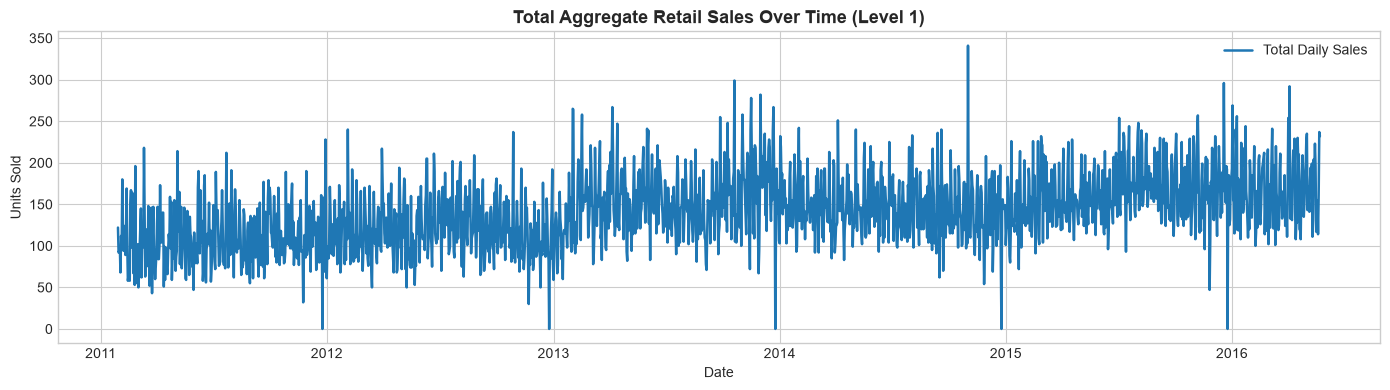

In [6]:
# Aggregate total sales over time
total_sales_ts = df.groupby("date")["sales"].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(
    total_sales_ts["date"],
    total_sales_ts["sales"],
    color="#1f77b4",
    lw=1.8,
    label="Total Daily Sales",
)
plt.title("Total Aggregate Retail Sales Over Time (Level 1)", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Hierarchical Sales Exploration (State, Category, Department)
We decompose the aggregate demand across different organizational hierarchies to observe state-level differences and department volume distributions.

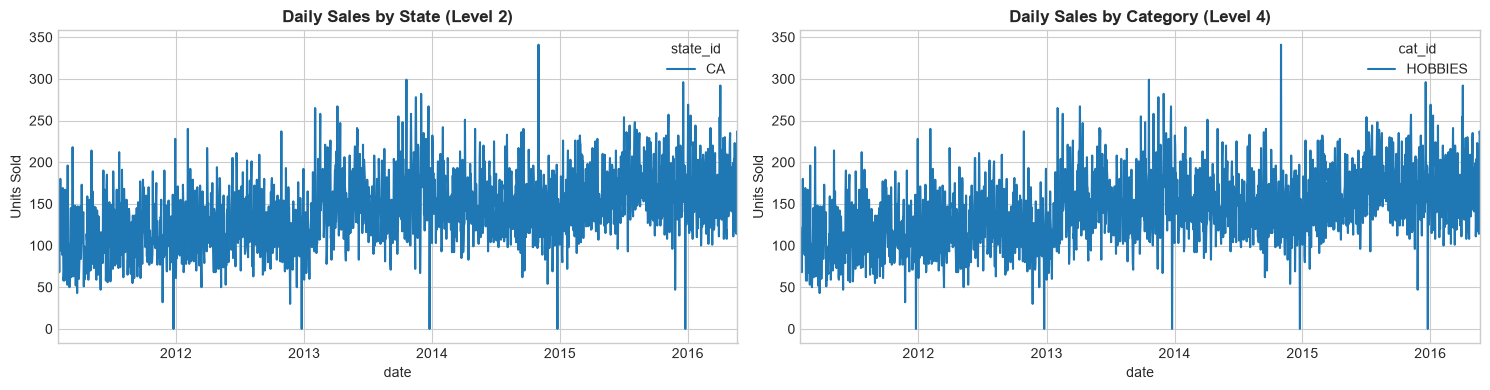

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# State level sales
state_ts = df.groupby(["date", "state_id"], observed=False)["sales"].sum().unstack()
state_ts.plot(ax=axes[0], lw=1.5)
axes[0].set_title("Daily Sales by State (Level 2)", fontweight="bold")
axes[0].set_ylabel("Units Sold")

# Category level sales
cat_ts = df.groupby(["date", "cat_id"], observed=False)["sales"].sum().unstack()
cat_ts.plot(ax=axes[1], lw=1.5)
axes[1].set_title("Daily Sales by Category (Level 4)", fontweight="bold")
axes[1].set_ylabel("Units Sold")

plt.tight_layout()
plt.show()

### Hierarchy Findings
- **Level 2 (State)**: Shows consistent volume ranking with California typically leading in volume.
- **Level 4 (Category)**: Food products dominate transaction volume and exhibits stronger weekend surges compared to Hobbies and Household.

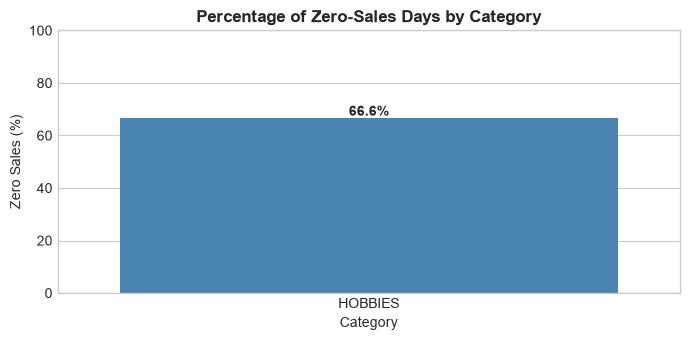

In [8]:
# Intermittency and Zero Distribution
zero_pct_by_cat = df.groupby("cat_id", observed=False)["sales"].apply(
    lambda x: (x == 0).mean() * 100
)

plt.figure(figsize=(7, 3.5))
sns.barplot(
    x=zero_pct_by_cat.index,
    y=zero_pct_by_cat.values,
    hue=zero_pct_by_cat.index,
    legend=False,
    palette="Blues_d",
)
plt.title("Percentage of Zero-Sales Days by Category", fontweight="bold")
plt.ylabel("Zero Sales (%)")
plt.xlabel("Category")
for i, v in enumerate(zero_pct_by_cat.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 4. Intermittency & Croston Classification
In retail demand forecasting, standard regression models perform poorly when demand is **zero-inflated** or **intermittent**.

Using the **Syntetos-Boylan Classification**:
- **Average Demand Interval (ADI)**: Average interval between non-zero demand periods ($ADI < 1.32$ indicates regular demand, $ADI \ge 1.32$ indicates intermittent).
- **Squared Coefficient of Variation ($CV^2$)**: Variance of non-zero demand size ($CV^2 < 0.49$ indicates smooth, $CV^2 \ge 0.49$ indicates erratic demand).

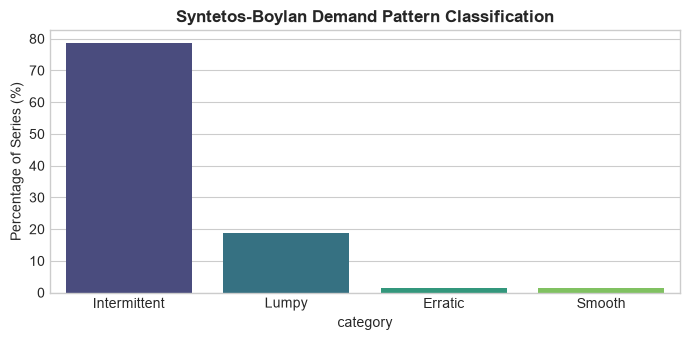

In [9]:
# Compute ADI and CV^2 for sample items
def compute_adi_cv2(series):
    non_zero = series[series > 0]
    if len(non_zero) < 2:
        return 10.0, 2.0
    adi = len(series) / len(non_zero)
    cv2 = (non_zero.std() / (non_zero.mean() + 1e-6)) ** 2
    return adi, cv2


item_stats = []
for series_id, grp in df.groupby("id", observed=False):
    adi, cv2 = compute_adi_cv2(grp["sales"].values)
    category = (
        "Smooth"
        if adi < 1.32 and cv2 < 0.49
        else "Intermittent"
        if adi >= 1.32 and cv2 < 0.49
        else "Erratic"
        if adi < 1.32 and cv2 >= 0.49
        else "Lumpy"
    )
    item_stats.append(
        {
            "id": series_id,
            "cat_id": str(grp["cat_id"].iloc[0]),
            "adi": adi,
            "cv2": cv2,
            "category": category,
        }
    )

stats_df = pd.DataFrame(item_stats)
cat_counts = stats_df["category"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 3.5))
sns.barplot(
    x=cat_counts.index, y=cat_counts.values, hue=cat_counts.index, legend=False, palette="viridis"
)
plt.title("Syntetos-Boylan Demand Pattern Classification", fontweight="bold")
plt.ylabel("Percentage of Series (%)")
plt.tight_layout()
plt.show()

### Intermittency Conclusion
A significant fraction of item-store series fall into **Intermittent** or **Lumpy** categories. This proves why:
1. Tweedie/Poisson loss functions in LightGBM and CatBoost are superior to MSE.
2. Specialized statistical models (Croston method) are required for baseline comparisons.

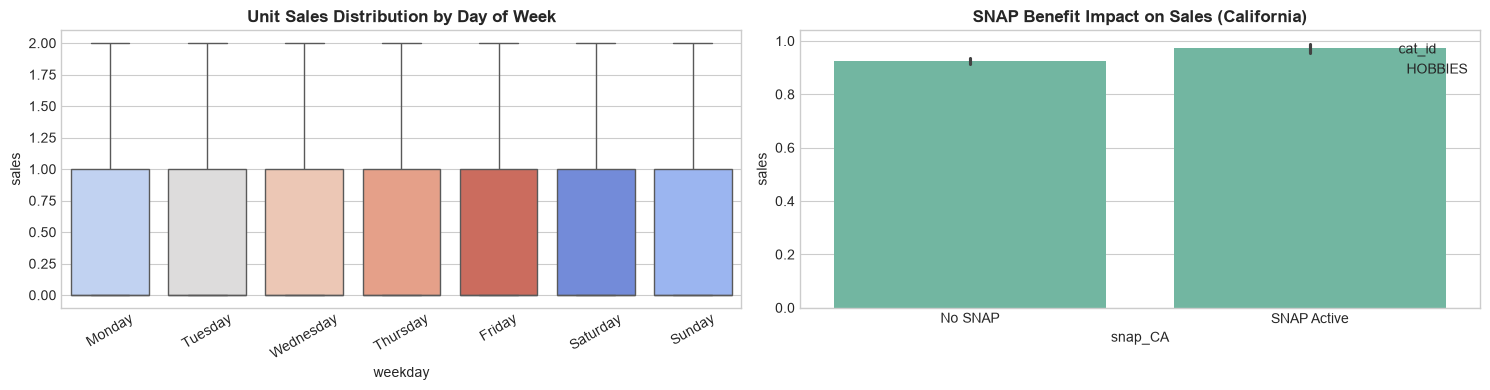

In [10]:
# Day of week and SNAP effect
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Day of week sales
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(
    data=df,
    x="weekday",
    y="sales",
    hue="weekday",
    legend=False,
    order=dow_order,
    ax=axes[0],
    showfliers=False,
    palette="coolwarm",
)
axes[0].set_title("Unit Sales Distribution by Day of Week", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

# SNAP impact in CA
if "snap_CA" in df.columns:
    ca_df = df[df["state_id"] == "CA"]
    if not ca_df.empty:
        sns.barplot(data=ca_df, x="snap_CA", y="sales", hue="cat_id", ax=axes[1], palette="Set2")
        axes[1].set_title("SNAP Benefit Impact on Sales (California)", fontweight="bold")
        axes[1].set_xticks([0, 1])
        axes[1].set_xticklabels(["No SNAP", "SNAP Active"])

plt.tight_layout()
plt.show()

## 5. Statistical Properties & Stationarity Analysis
We evaluate the stationarity of aggregate and series-level sales using **Augmented Dickey-Fuller (ADF)** and **KPSS** tests.

In [11]:
# ADF & KPSS on total sales series
ts = total_sales_ts["sales"].values

adf_res = adfuller(ts)
kpss_res = kpss(ts, regression="c", nlags="auto")

print("=== Stationarity Test Results (Total Sales Series) ===")
print(f"ADF Test Statistic: {adf_res[0]:.4f} (p-value: {adf_res[1]:.4e})")
print(f"KPSS Test Statistic: {kpss_res[0]:.4f} (p-value: {kpss_res[1]:.4e})")

if adf_res[1] < 0.05 and kpss_res[1] >= 0.05:
    print("Conclusion: Series is Stationary.")
elif adf_res[1] >= 0.05 and kpss_res[1] < 0.05:
    print("Conclusion: Series is Non-Stationary (trend/seasonality present).")
else:
    print("Conclusion: Series exhibits strong weekly/annual seasonality and intermittent shocks.")

=== Stationarity Test Results (Total Sales Series) ===
ADF Test Statistic: -2.8243 (p-value: 5.4882e-02)
KPSS Test Statistic: 6.5858 (p-value: 1.0000e-02)
Conclusion: Series is Non-Stationary (trend/seasonality present).


C:\Users\Beka\AppData\Local\Temp\ipykernel_12340\4072562230.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(ts, regression="c", nlags="auto")


## 6. Comprehensive Summary & Modeling Takeaways

### Key Insights:
1. **Hierarchical Coherence**: Significant aggregation variance from Level 1 down to Level 12. Bottom-up predictions alone introduce variance; hierarchical reconciliation (MinT / Top-Down) will improve coherence.
2. **Intermittent Demand**: Item-level demand has a high percentage of zero-sales days (often > 40%). Objective functions like **Tweedie loss** ($p \approx 1.15$) and Croston method are essential.
3. **Exogenous Features**: Strong weekly cycles (Saturday/Sunday peak) and SNAP benefit cycles (first 10-15 days of the month for food items) provide critical predictive signal.
4. **Next Steps**:
   - Milestone 2: Build rolling-window backtesting framework and evaluate Naive / Seasonal Naive / Moving Average baselines on the WRMSSE metric.